Import master data set 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import guild dataset
data = pd.read_csv('../r_honours/outputs/master_data_with_guilds.csv')
data = data[data['guild'].notna()]

# inspect
print(f"shape: {data.shape}")
print(f"guilds: {sorted(data['guild'].unique())}")
print(f"\nrecords per guild:")
print(data.groupby(['guild', 'guild_name']).size())

data.head()

shape: (32181, 72)
guilds: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0]

records per guild:
guild  guild_name                
1.0    large owls                      901
2.0    small passerines               5962
3.0    medium burrowing mammals        286
4.0    large snakes                    126
5.0    medium ground birds            6037
6.0    large carnivorous mammals        28
7.0    small cavity-nesting birds     3576
8.0    insectivorous bats               37
9.0    small nocturnal rodents         252
10.0   small reptiles                   16
11.0   small woodland birds          14960
dtype: int64


/var/folders/1g/l5k4r0115td0c8pd06wt1qcr0000gn/T/ipykernel_40767/2475375305.py:7: DtypeWarning: Columns (60) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../r_honours/outputs/master_data_with_guilds.csv')


,name_clean,class,phylum,order,family,genus,species,decimalLatitude,decimalLongitude,tmax,...,scientificName,verbatimScientificName,occurrenceStatus,individualCount,eventDate,taxonKey,speciesKey,basisOfRecord,guild,guild_name
0,Columbina inca,Aves,Chordata,Columbiformes,Columbidae,Columbina,Columbina inca,31.9588,-109.3137,35.0,...,"Columbina inca (R.Lesson, 1847)",Columbina inca,PRESENT,NaN,1930-02-24,2495863,2495863,PRESERVED_SPECIMEN,5.0,medium ground birds
1,Cyanocitta stelleri,Aves,Chordata,Passeriformes,Corvidae,Cyanocitta,Cyanocitta stelleri,31.9297,-109.3817,31.8,...,"Cyanocitta stelleri macrolopha S.F.Baird, 1854",Cyanocitta stelleri macrolopha,PRESENT,NaN,1958-10-01/1958-10-31,6171802,2482598,PRESERVED_SPECIMEN,11.0,small woodland birds
2,Callipepla gambelii,Aves,Chordata,Galliformes,Odontophoridae,Callipepla,Callipepla gambelii,31.9588,-109.3137,40.5,...,"Callipepla gambelii gambelii (Gambel, 1843)",Callipepla gambelii gambelii,PRESENT,NaN,1919-05-25,5228073,5228072,PRESERVED_SPECIMEN,5.0,medium ground birds
3,Cyanocitta stelleri,Aves,Chordata,Passeriformes,Corvidae,Cyanocitta,Cyanocitta stelleri,31.8664,-109.3464,31.8,...,"Cyanocitta stelleri macrolopha S.F.Baird, 1854",Cyanocitta stelleri macrolopha,PRESENT,NaN,1951-11-03,6171802,2482598,PRESERVED_SPECIMEN,11.0,small woodland birds
4,Micrathene whitneyi,Aves,Chordata,Strigiformes,Strigidae,Micrathene,Micrathene whitneyi,31.9297,-109.3817,38.0,...,"Micrathene whitneyi whitneyi (J.G.Cooper, 1861)",Micrathene whitneyi whitneyi,PRESENT,NaN,1919-07-11,7191241,2497430,PRESERVED_SPECIMEN,11.0,small woodland birds


In [2]:
print("Columns:", data.columns)
print("Shape:", data.shape)


Columns: Index(['name_clean', 'class', 'phylum', 'order', 'family', 'genus', 'species',
       'decimalLatitude', 'decimalLongitude', 'tmax', 'tmin', 'body_mass_g',
       'adult_weight_g', 'max_longevity_yrs', 'metabolic_rate_w',
       'female_maturity_days', 'male_maturity_days', 'elevation_m',
       'bio1_current', 'bio2_current', 'bio3_current', 'bio4_current',
       'bio5_current', 'bio6_current', 'bio7_current', 'bio8_current',
       'bio9_current', 'bio10_current', 'bio11_current', 'bio12_current',
       'bio13_current', 'bio14_current', 'bio15_current', 'bio16_current',
       'bio17_current', 'bio18_current', 'bio19_current', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ott_id', 'phylum_gt', 'class_gt', 'order_gt',
       'infraspecificEpithet', 'taxonRank', 'scientificName',
       'verbatimScientificName', 'occurrenceStatus', 'indivi

##Visualising spatial bias

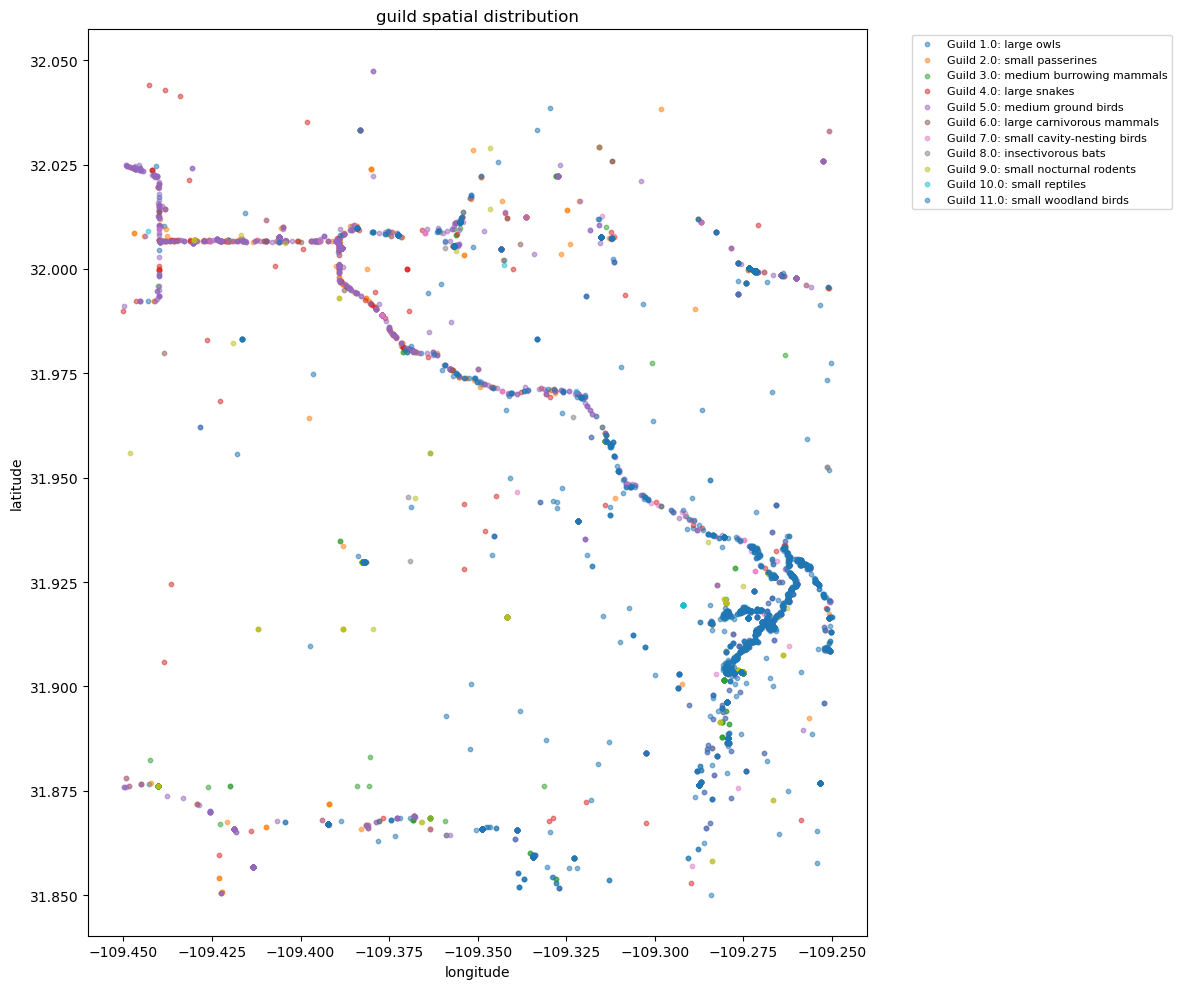

In [3]:
import matplotlib.pyplot as plt

# visualize guild distributions spatially
fig, ax = plt.subplots(figsize=(12, 10))

for guild_id in sorted(data['guild'].unique()):
    guild_data = data[data['guild'] == guild_id]
    ax.scatter(guild_data['decimalLongitude'], 
               guild_data['decimalLatitude'],
               label=f"Guild {guild_id}: {guild_data['guild_name'].iloc[0]}",
               alpha=0.5, s=10)

ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_title('guild spatial distribution')
plt.tight_layout()
plt.show()

# Exploring factors influencing sightings and environmental trait diversity

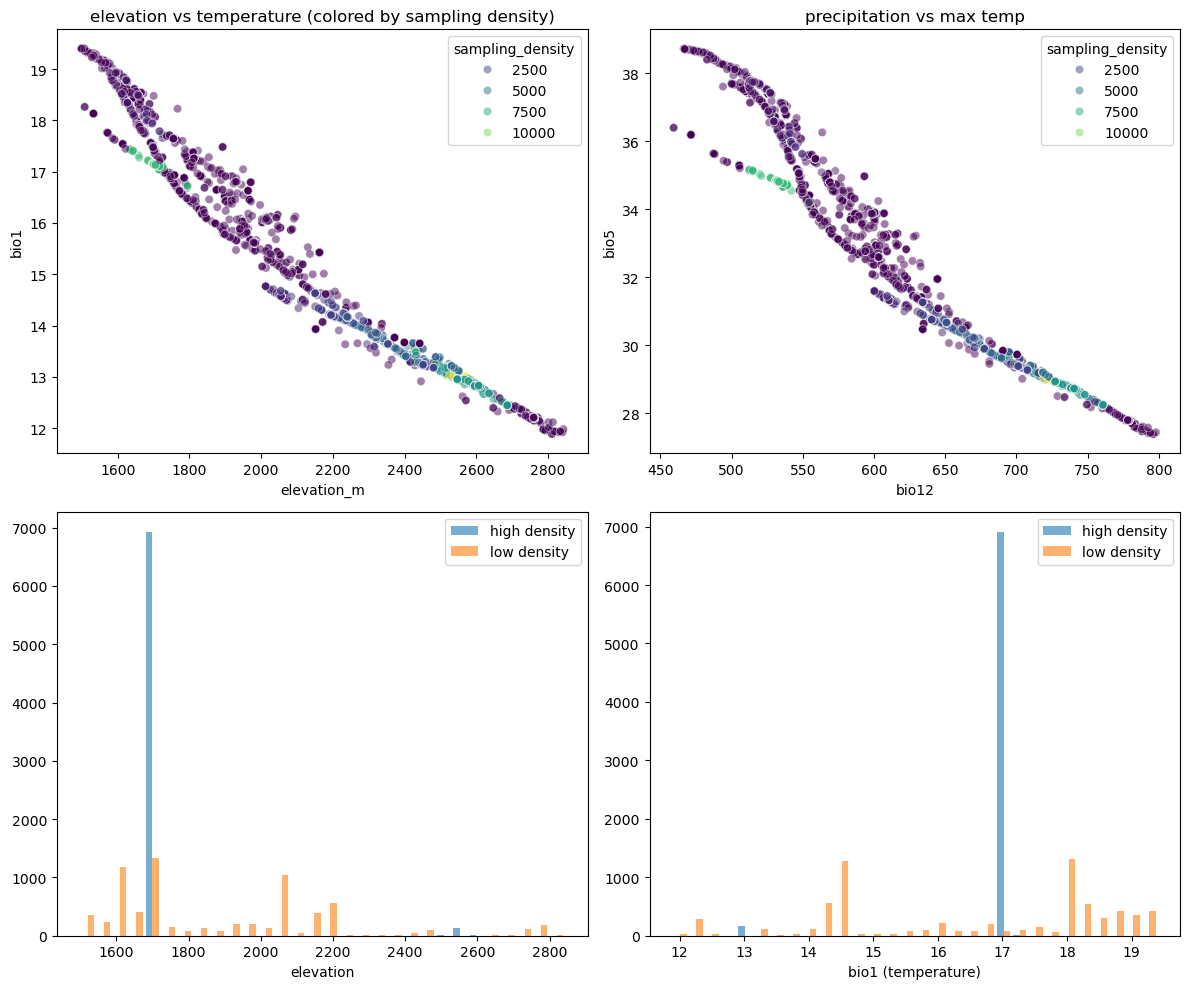

=== environmental coverage check ===
elevation range (all): 1498 - 2842m
elevation range (high density): 1658 - 2584m

bio1 range (all): 12 - 19
bio1 range (high density): 13 - 17


In [4]:
import seaborn as sns

# check if biased samples cover full environmental range
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# create sampling density categories
from scipy.spatial import KDTree
coords = data[['decimalLongitude', 'decimalLatitude']].values
tree = KDTree(coords)
# count neighbors within 0.01 degrees (~1km)
neighbor_counts = [len(tree.query_ball_point(coord, 0.01)) for coord in coords]
data['sampling_density'] = neighbor_counts

# plot environmental coverage by sampling density
sns.scatterplot(data=data, x='elevation_m', y='bio1', 
                hue='sampling_density', palette='viridis',
                alpha=0.5, ax=axes[0,0])
axes[0,0].set_title('elevation vs temperature (colored by sampling density)')

sns.scatterplot(data=data, x='bio12', y='bio5', 
                hue='sampling_density', palette='viridis',
                alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('precipitation vs max temp')

# check if high-density areas cover environmental range
high_density = data[data['sampling_density'] > data['sampling_density'].quantile(0.75)]
low_density = data[data['sampling_density'] < data['sampling_density'].quantile(0.25)]

axes[1,0].hist([high_density['elevation_m'], low_density['elevation_m']], 
               label=['high density', 'low density'], alpha=0.6, bins=30)
axes[1,0].set_xlabel('elevation')
axes[1,0].legend()

axes[1,1].hist([high_density['bio1'], low_density['bio1']], 
               label=['high density', 'low density'], alpha=0.6, bins=30)
axes[1,1].set_xlabel('bio1 (temperature)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print("=== environmental coverage check ===")
print(f"elevation range (all): {data['elevation_m'].min():.0f} - {data['elevation_m'].max():.0f}m")
print(f"elevation range (high density): {high_density['elevation_m'].min():.0f} - {high_density['elevation_m'].max():.0f}m")
print(f"\nbio1 range (all): {data['bio1'].min():.0f} - {data['bio1'].max():.0f}")
print(f"bio1 range (high density): {high_density['bio1'].min():.0f} - {high_density['bio1'].max():.0f}")